# Create Figures 1 and 2:  
This notebook plots: 
* Reference map of Sierra Nevada domain within the Western US 
* Sierra Nevada elevation map from USGS 3DEP
* Snowy study domain within Sierra Nevada and elevation data from an example ICESat-2 acquisition date
* Snow depth calculated from that example ICESat-2 date
* Density hexbin maps of ICESat-2 coverage during December - June (approximate snow-on timing)
* An inset of the example ICESat-2 date, with slope plotted and >20 degrees greyed out, canopy cover in green, and snow depth from ICESat-2
* The same inset of that ICESat-2 date showing satellite imagery of the region

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd 
from pathlib import Path
import py3dep
import pickle
from shapely.geometry import Polygon
import xarray as xr

In [22]:
sierras = gpd.read_file('../../data/misc/sierra_simplified.geojson')

In [3]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_22Oct2025_masked_lowslope.pkl', 'rb'))

In [40]:
atl06sr_gdf['n'] = atl06sr_gdf.groupby('acqdate')['acqdate'].transform('count')

In [61]:
atl06sr_gdf = atl06sr_gdf[atl06sr_gdf['n']>100]

## Figure 1

### Reference map:

In [58]:
usa = gpd.read_file('../../data/misc/cb_2018_us_state_500k/cb_2018_us_state_500k.shp')

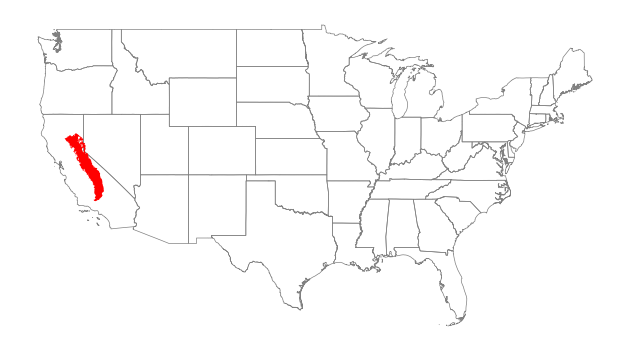

In [60]:
non_conus = ['Alaska', 'Hawaii', 'Puerto Rico', 
              'American Samoa', 'Commonwealth of the Northern Mariana Islands', 
              'Guam', 'United States Virgin Islands']

fig, ax = plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
usa[~usa['NAME'].isin(non_conus)].to_crs('epsg:4326').plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
sierras.plot(ax=ax, facecolor="red")

ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
plt.savefig('../../figures/sierras_locationoutilne_us.png', dpi=500)

### Access coarsened 3dep data for plotting:
Only run once, otherwise read in saved data

In [29]:
# sierras_bbox = (-121.95, 34.82, -117.86, 40.45)

# dem_200 = py3dep.get_map("DEM", sierras_bbox, resolution=200, geo_crs=4326, crs=4326)

# sierras_200 = dem_200.rio.clip(sierras.geometry, sierras.crs, drop=True)

# sierras_200.to_netcdf('../../data/misc/dem_200m_sierras.nc')

sierras_200 = xr.open_dataset('../../data/misc/dem_200m_sierras.nc')

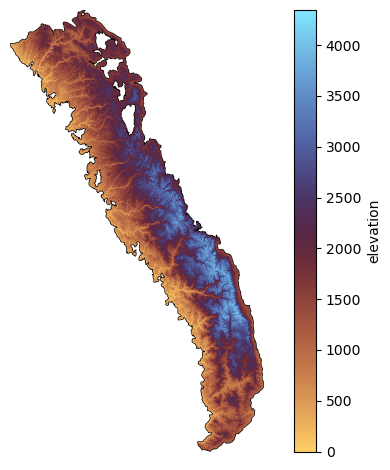

In [34]:
fig, ax = plt.subplots()

sierras_200.elevation.plot(ax=ax, cmap='managua', vmin=0, label='Elevation (m)')
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
plt.savefig('../../figures/sierras_dem_200m.png', dpi=500)

In [38]:
print('Min elevation: ', sierras_200['elevation'].min().values)
print('Max elevation: ',sierras_200['elevation'].max().values)

Min elevation:  68.63861083984375
Max elevation:  4345.8466796875


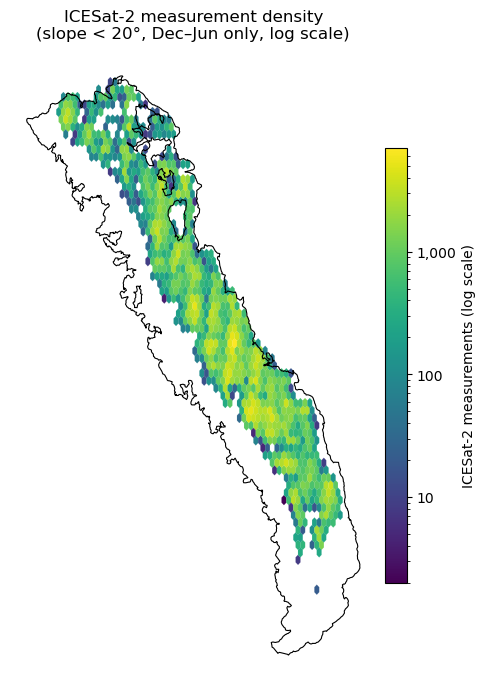

In [62]:
import matplotlib.colors as mcolors
import matplotlib.ticker

snow_season = atl06sr_gdf[
    atl06sr_gdf['acqdate_dt'].dt.month.isin([12, 1, 2, 3, 4, 5, 6])
]
snow_season_proj     = snow_season.to_crs('EPSG:3310')
sierra_proj = sierras.to_crs('EPSG:3310')

lons = snow_season_proj.geometry.x.values  # meters, California Albers
lats = snow_season_proj.geometry.y.values

fig, ax = plt.subplots(figsize=(5, 9))

sierra_proj.boundary.plot(ax=ax, edgecolor='k', linewidth=0.8)

hb = ax.hexbin(lons, lats, gridsize=60, cmap='viridis',
               mincnt=2, linewidths=0.1,
               norm=mcolors.LogNorm())

cb = fig.colorbar(hb, ax=ax, shrink=0.5, pad=0.02)
cb.set_label('ICESat-2 measurements (log scale)')
cb.ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.set_title('ICESat-2 measurement density\n(slope < 20°, Dec–Jun only, log scale)')
ax.set_aspect('equal')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('../../figures/icesat2_density_logscale.png', dpi=500)
plt.show()

### Use a highlight date to show an acquisition date:

In [42]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../../analog_snowmapping/swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [43]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) )).compute()


In [44]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1_mean = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True).compute()

In [45]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1_mean.SCA_Post > 0.5

In [49]:
swe_sca_ds_roi = swe_sca_ds_allyrs.SCA_Post.where(mask)

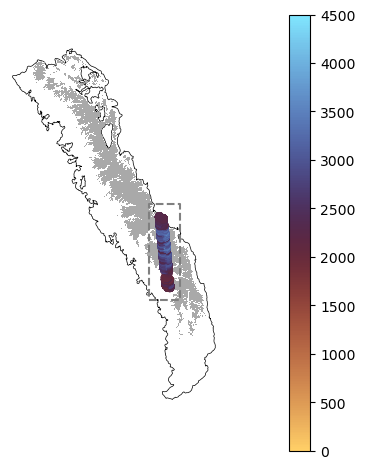

In [52]:
highlight_date = pd.to_datetime('2021-04-07')

min_x = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.x.min()
min_y = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.y.min()
max_x = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.x.max()
max_y = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.y.max()

buffer = 0.2

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax =plt.subplots()
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)

sd_roi = swe_sca_ds_roi.sel(time='2020-04-01').rio.clip(sierras.geometry, drop=False)
(sd_roi * 0 + 1).plot(ax=ax, cmap=mcolors.ListedColormap(['#A9A9A9']),
                      vmin=0.5, vmax=1.5, add_colorbar=False)

atl06sr_gdf[atl06sr_gdf['acqdate_dt']==highlight_date].plot(ax=ax, 
            column='h_mean',markersize=30, cmap='managua', legend=True, vmin=0, vmax=4500)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
plt.savefig('../../figures/sierras_inset_location_april72021_slope_20.png', dpi=500)


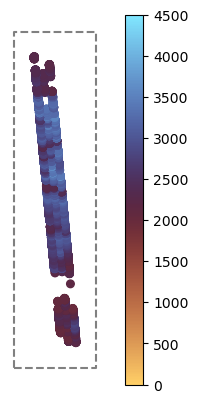

In [53]:
min_x = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.x.min()
min_y = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.y.min()
max_x = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.x.max()
max_y = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.y.max()

buffer = 0.1

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


buffer2 = 0.05

min_x2 = -118.84 + buffer2
min_y2 = 37.175 + buffer2
max_x2 = -118.922 - buffer2
max_y2 = 37.2 - buffer2

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]


# ax.set_ylim(37.175,37.2)
# ax.set_xlim(-118.84,-118.922)


fig, ax =plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf[atl06sr_gdf['acqdate_dt']==highlight_date].plot(ax=ax, 
        column='h_mean',markersize=30, cmap='managua', legend=True, vmin=0, vmax=4500) # , edgecolor='k', linewidth=0.1
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
#ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

ax.set_axis_off()
plt.savefig('../../figures/sierras_inset_location_elevation_april72021_slope_20.png', dpi=500)

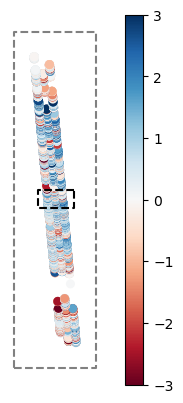

In [57]:
min_x = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.x.min()
min_y = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.y.min()
max_x = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.x.max()
max_y = atl06sr_gdf.loc[(atl06sr_gdf['acqdate_dt']==highlight_date) & (atl06sr_gdf['n']>100)].geometry.y.max()

buffer = 0.1

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


buffer2 = 0.05

min_x2 = -118.84 + buffer2
min_y2 = 37.175 + buffer2
max_x2 = -118.922 - buffer2
max_y2 = 37.2 - buffer2

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]


# ax.set_ylim(37.175,37.2)
# ax.set_xlim(-118.84,-118.922)


fig, ax =plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf[atl06sr_gdf['acqdate_dt']==highlight_date].plot(ax=ax, 
        column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')
#ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

ax.set_axis_off()
plt.savefig('../../figures/sierras_inset_location_snowdepth_april72021_slope_20.png', dpi=500)

## Figure 2

### Access slope data from 3DEP program for inset region:

In [74]:
import rioxarray as rxr
import subprocess, os

url = "/vsicurl/https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/13/TIFF/USGS_Seamless_DEM_13.vrt"

target_minx, target_miny, target_maxx, target_maxy = -118.927, 37.175, -118.84, 37.2
buf = 0.02

dem = rxr.open_rasterio(url, masked=True).squeeze()
dem_buffered = dem.rio.clip_box(
    minx=target_minx - buf, miny=target_miny - buf,
    maxx=target_maxx + buf, maxy=target_maxy + buf,
    crs='EPSG:4326'
)
dem_buffered.rio.to_raster('/tmp/dem_wgs84.tif')

# Remove output files if they exist (gdaldem doesn't support -overwrite)
for f in ['/tmp/dem_utm.tif', '/tmp/slope_utm.tif', '/tmp/slope_wgs84.tif']:
    if os.path.exists(f): os.remove(f)

subprocess.run(['gdalwarp', '-t_srs', 'EPSG:32611', '-r', 'bilinear',
                '/tmp/dem_wgs84.tif', '/tmp/dem_utm.tif'], check=True, capture_output=True)
subprocess.run(['gdaldem', 'slope', '/tmp/dem_utm.tif', '/tmp/slope_utm.tif'],
               check=True, capture_output=True)
subprocess.run(['gdalwarp', '-t_srs', 'EPSG:4326', '-r', 'bilinear',
                '/tmp/slope_utm.tif', '/tmp/slope_wgs84.tif'], check=True, capture_output=True)

slope_full = rxr.open_rasterio('/tmp/slope_wgs84.tif', masked=True).squeeze()
slope_crs_alt = slope_full.rio.clip_box(
    minx=target_minx, miny=target_miny,
    maxx=target_maxx, maxy=target_maxy
)


### Load in land cover data and identify vegetation cover:

In [67]:
import rioxarray as rxr
from pyproj import Transformer
import numpy as np

tif_fn = '../../data/land_cover/NA_NALCMS_landcover_2020v2_30m.tif'

veg = rxr.open_rasterio(tif_fn, masked=True).sel(band=1)

# Transform all 4 corners of the WGS84 target to native CRS
# (2-corner transform misses NW/SE corners when axes are rotated)
transformer = Transformer.from_crs('EPSG:4326', veg.rio.crs, always_xy=True)
corners_lon = [-118.927, -118.84, -118.927, -118.84]
corners_lat = [37.175,   37.175,  37.2,     37.2]
native_x, native_y = transformer.transform(corners_lon, corners_lat)
native_minx, native_maxx = float(np.min(native_x)), float(np.max(native_x))
native_miny, native_maxy = float(np.min(native_y)), float(np.max(native_y))

veg_clipped = veg.rio.clip_box(minx=native_minx, miny=native_miny,
                               maxx=native_maxx, maxy=native_maxy)
veg_clipped = veg_clipped.rio.reproject('EPSG:4326')
# Trim to exact WGS84 target extent
veg_clipped = veg_clipped.rio.clip_box(minx=-118.927, miny=37.175,
                                       maxx=-118.84,  maxy=37.2)


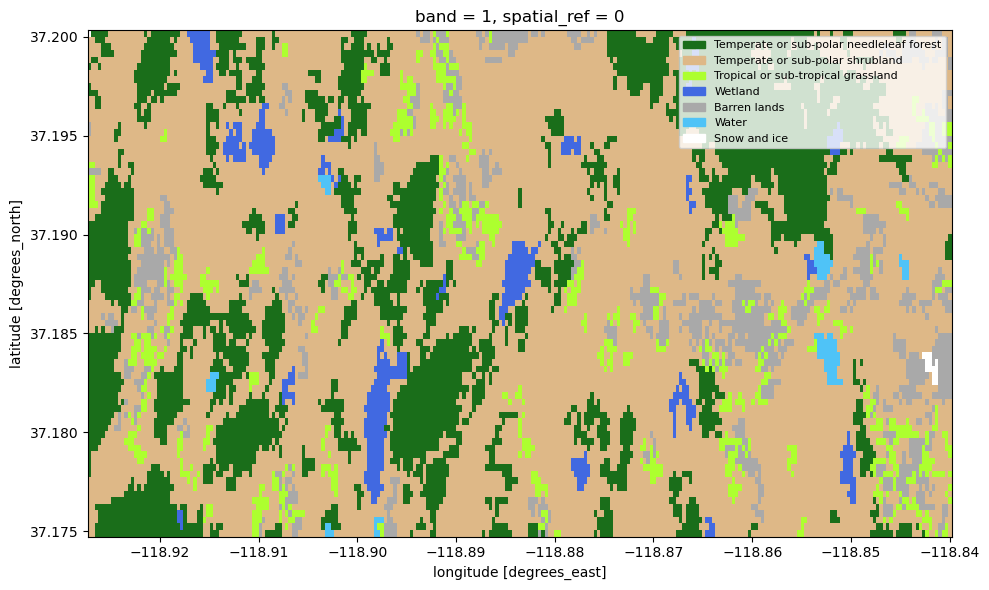

In [68]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

nalcms_labels = {
    1: 'Temperate or sub-polar needleleaf forest',
    2: 'Sub-polar taiga needleleaf forest',
    3: 'Tropical or sub-tropical broadleaf evergreen forest',
    4: 'Tropical or sub-tropical broadleaf deciduous forest',
    5: 'Temperate or sub-polar broadleaf deciduous forest',
    6: 'Mixed forest',
    7: 'Tropical or sub-tropical shrubland',
    8: 'Temperate or sub-polar shrubland',
    9: 'Sub-polar or polar shrubland-lichen-moss',
    10: 'Tropical or sub-tropical grassland',
    11: 'Temperate or sub-polar grassland',
    12: 'Sub-polar or polar grassland-lichen-moss',
    13: 'Sub-polar or polar barren-lichen-moss',
    14: 'Wetland',
    15: 'Cropland',
    16: 'Barren lands',
    17: 'Urban and built-up',
    18: 'Water',
    19: 'Snow and ice'
}

nalcms_colors = {
    1:  '#1a6e1a',  # needleleaf forest — dark green
    2:  '#4aab4a',  # taiga — medium green
    3:  '#00cc00',  # tropical evergreen — bright green
    4:  '#79c679',  # tropical deciduous — light green
    5:  '#52a552',  # temperate deciduous — mid green
    6:  '#8fbc8f',  # mixed forest — sage green
    7:  '#c8864b',  # tropical shrubland — orange-brown
    8:  '#deb887',  # temperate shrubland — burlywood
    9:  '#f5deb3',  # sub-polar shrubland — wheat
    10: '#adff2f',  # tropical grassland — yellow-green
    11: '#eee8aa',  # temperate grassland — pale goldenrod
    12: '#90ee90',  # sub-polar grassland — light green
    13: '#c8c8c8',  # polar barren — light gray
    14: '#4169e1',  # wetland — royal blue
    15: '#ffd700',  # cropland — gold
    16: '#a9a9a9',  # barren lands — gray
    17: '#ff4500',  # urban — orange-red
    18: '#4fc3f7',  # water — light blue
    19: '#ffffff',  # snow and ice — white
}

# Find categories present in this subset
arr = veg_clipped.values.astype(float)
unique_vals = np.unique(arr[~np.isnan(arr)]).astype(int)
colors_present = [nalcms_colors[v] for v in unique_vals]
labels_present = [nalcms_labels[v] for v in unique_vals]

# Remap to consecutive indices for BoundaryNorm
remapped = np.full_like(arr, np.nan)
for i, v in enumerate(unique_vals):
    remapped[arr == v] = i
veg_remapped = veg_clipped.copy(data=remapped)

n = len(unique_vals)
cmap = mcolors.ListedColormap(colors_present)
norm = mcolors.BoundaryNorm(np.arange(n + 1) - 0.5, n)

fig, ax = plt.subplots(figsize=(10, 6))
veg_remapped.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
patches = [mpatches.Patch(color=colors_present[i], label=labels_present[i])
           for i in range(n)]
ax.legend(handles=patches, fontsize=8, loc='best')
plt.tight_layout()
plt.show()


In [75]:
# Vegetation overlay (semi-transparent)
from rasterio.enums import Resampling
forest_classes = [1, 2, 3, 4, 5, 6]
veg_arr = veg_clipped.values.astype(float)
forest_mask = np.where(np.isin(veg_arr, forest_classes), 1.0, np.nan)
veg_forest = veg_clipped.copy(data=forest_mask)
veg_forest_matched = veg_forest.rio.reproject_match(slope_crs_alt, resampling=Resampling.nearest)

### Access satellite imagery:

In [76]:
import mercantile
import requests
from PIL import Image
import io

bbox = [-118.927, 37.175, -118.84, 37.2]
zoom = 14
tile_url = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'

tiles = list(mercantile.tiles(bbox[0], bbox[1], bbox[2], bbox[3], zooms=zoom))
xs = [t.x for t in tiles]
ys = [t.y for t in tiles]
min_x, max_x = min(xs), max(xs)
min_y, max_y = min(ys), max(ys)

rows = []
for ty in range(min_y, max_y + 1):
    row_imgs = []
    for tx in range(min_x, max_x + 1):
        url = tile_url.format(z=zoom, x=tx, y=ty)
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        row_imgs.append(np.array(Image.open(io.BytesIO(resp.content)).convert('RGB')))
    rows.append(np.concatenate(row_imgs, axis=1))
stitched = np.concatenate(rows, axis=0)

ul = mercantile.ul(min_x, min_y, zoom)
lr = mercantile.ul(max_x + 1, max_y + 1, zoom)
print('Tiles downloaded.')


Tiles downloaded.


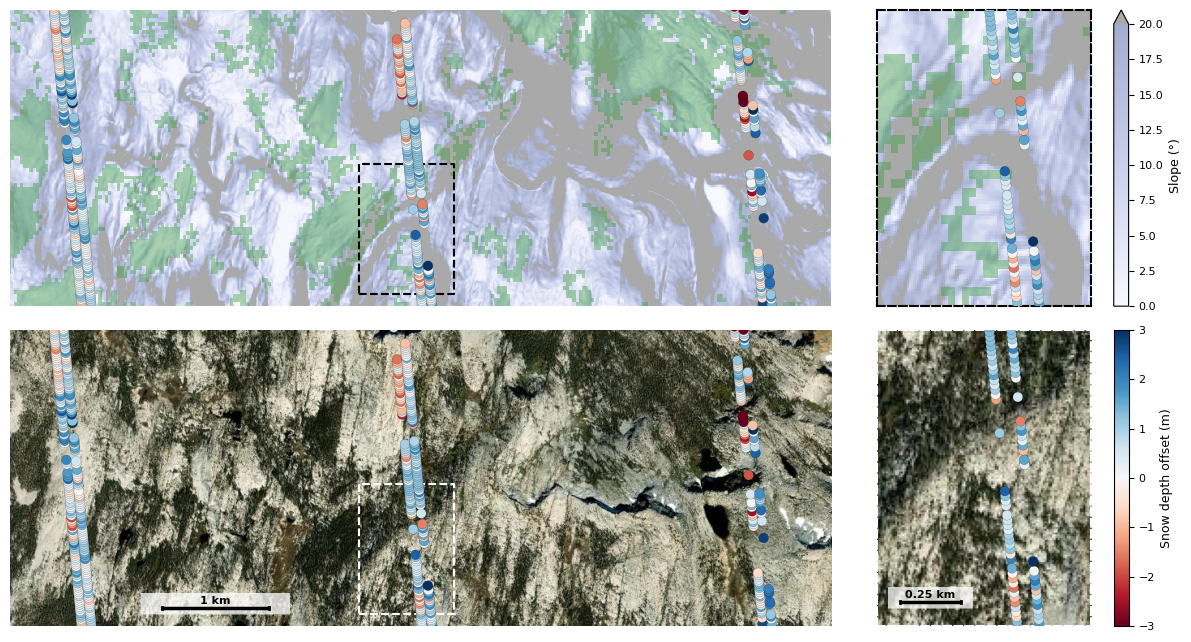

In [77]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 4, figure=fig, width_ratios=[3.5, 1, 0.06, 0.06], hspace=0.08, wspace=0.02)
ax1            = fig.add_subplot(gs[0, 0])
ax1_inset      = fig.add_subplot(gs[0, 1])
ax_cbar_slope  = fig.add_subplot(gs[0, 2])
ax_cbar_is2    = fig.add_subplot(gs[1, 2])
ax2            = fig.add_subplot(gs[1, 0])
ax2_inset      = fig.add_subplot(gs[1, 1])

colors2 = ['#F8F8FF', '#C8D0EC', '#A4ADCE']
custom_cmap = mcolors.LinearSegmentedColormap.from_list('my_custom_cmap', colors2)
custom_cmap.set_over('#A9A9A9')
norm1 = mcolors.Normalize(vmin=0, vmax=20)

inset_xlim = (-118.89, -118.88)
inset_ylim = (37.176, 37.187)

def plot_slope_veg(ax):
    slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1, add_colorbar=False)
    veg_forest.plot(ax=ax, cmap=mcolors.ListedColormap(['#3a9e3a']),
                            vmin=0.5, vmax=1.5, alpha=0.4, add_colorbar=False, zorder=2)
    atl06sr_gdf[atl06sr_gdf['acqdate_dt']==highlight_date].plot(
        ax=ax, column='icesat2_3dep_dif', markersize=50, cmap='RdBu',
        edgecolor='k', linewidth=0.1, vmin=-3, vmax=3, legend=False, zorder=3)

def plot_imagery(ax):
    ax.imshow(stitched, extent=[ul.lng, lr.lng, lr.lat, ul.lat], aspect='auto')
    atl06sr_gdf[atl06sr_gdf['acqdate_dt']==highlight_date].plot(
        ax=ax, column='icesat2_3dep_dif', markersize=50, cmap='RdBu',
        edgecolor='k', linewidth=0.1, vmin=-3, vmax=3, legend=False, zorder=3)

def style_inset_border(ax, color):
    ax.set_axis_on()
    for spine in ax.spines.values():
        spine.set_linestyle('--')
        spine.set_edgecolor(color)
        spine.set_linewidth(1.5)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Redefine region box to match new inset extent
region = [
    {'lon': -118.89, 'lat': 37.176},
    {'lon': -118.88, 'lat': 37.176},
    {'lon': -118.88, 'lat': 37.187},
    {'lon': -118.89, 'lat': 37.187},
    {'lon': -118.89, 'lat': 37.176},
]
region_lon = [e['lon'] for e in region]
region_lat = [e['lat'] for e in region]

# Main panels
plot_slope_veg(ax1)
ax1.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax1.set_xlim(-118.927, -118.84)
ax1.set_ylim(37.175, 37.2)
ax1.set_title('') # Slope & vegetation
ax1.set_axis_off()

plot_imagery(ax2)
ax2.plot(region_lon, region_lat, linewidth=1.5, color='w', linestyle='--')
ax2.set_xlim(-118.927, -118.84)
ax2.set_ylim(37.175, 37.2)
ax2.set_title('') #True color (ESRI World Imagery)
ax2.set_axis_off()

# Inset panels
plot_slope_veg(ax1_inset)
ax1_inset.set_xlim(*inset_xlim)
ax1_inset.set_ylim(*inset_ylim)
ax1_inset.set_title('') #Inset
style_inset_border(ax1_inset, 'k')
ax1_inset.set_xlabel('')
ax1_inset.set_ylabel('')

plot_imagery(ax2_inset)
ax2_inset.set_xlim(*inset_xlim)
ax2_inset.set_ylim(*inset_ylim)
ax2_inset.set_title('') #Inset
style_inset_border(ax2_inset, 'w')

# Colorbars for top row
sm_slope = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm1)
sm_slope.set_array([])
cb_slope = fig.colorbar(sm_slope, cax=ax_cbar_slope, extend='max')
cb_slope.set_label('Slope (°)', fontsize=9)
cb_slope.ax.tick_params(labelsize=8)

sm_is2 = plt.cm.ScalarMappable(cmap='RdBu', norm=mcolors.Normalize(vmin=-3, vmax=3))
sm_is2.set_array([])
cb_is2 = fig.colorbar(sm_is2, cax=ax_cbar_is2)
cb_is2.set_label('Snow depth offset (m)', fontsize=9)
cb_is2.ax.tick_params(labelsize=8)


def add_scale_bar(ax, length_km, lat, x_center_frac=0.33, y0_frac=0.06, color='k'):
    import numpy as np
    from matplotlib.patches import FancyBboxPatch
    lon_min, lon_max = ax.get_xlim()
    lat_min, lat_max = ax.get_ylim()
    deg_per_km = 1.0 / (111.0 * np.cos(np.deg2rad(lat)))
    length_deg = length_km * deg_per_km
    x_center = lon_min + x_center_frac * (lon_max - lon_min)
    x0 = x_center - length_deg / 2
    x1 = x_center + length_deg / 2
    y0 = lat_min + y0_frac * (lat_max - lat_min)
    tick_h = 0.003 * (lat_max - lat_min)
    label_h = 2.2 * tick_h
    # Background box: bottom below bar, top well above label text
    pad_x = 0.2 * length_deg
    pad_y = 6 * tick_h
    top_pad = 15.0 * tick_h  # generous headroom above label
    y_bot = y0 - tick_h - pad_y
    y_top = y0 + label_h + top_pad
    bg = FancyBboxPatch(
        (x0 - pad_x, y_bot),
        length_deg + 2 * pad_x,
        y_top - y_bot,
        boxstyle='round,pad=0', facecolor='white', edgecolor='none', alpha=0.75, zorder=9
    )
    ax.add_patch(bg)
    # Bar and ticks
    ax.plot([x0, x1], [y0, y0], color=color, linewidth=2.5, solid_capstyle='butt', zorder=10)
    for x in [x0, x1]:
        ax.plot([x, x], [y0 - tick_h, y0 + tick_h], color=color, linewidth=2, zorder=10)
    ax.text(x_center, y0 + label_h,
            f'{length_km} km', ha='center', va='bottom',
            fontsize=8, color=color, fontweight='bold', zorder=10)

mid_lat = (37.175 + 37.2) / 2
add_scale_bar(ax2, length_km=1, lat=mid_lat, x_center_frac=0.25, y0_frac=0.06, color='k')

mid_lat_inset = (37.176 + 37.187) / 2
add_scale_bar(ax2_inset, length_km=0.25, lat=mid_lat_inset, x_center_frac=0.25, y0_frac=0.08, color='k')

plt.savefig('../../figures/slope_veg_imagery_composite.png', dpi=500, bbox_inches='tight')

plt.show()

### Satellite data return interval results:

In [65]:
import numpy as np

unique_dates = np.sort(atl06sr_gdf['acqdate_dt'].unique())
intervals = np.diff(unique_dates).astype('timedelta64[D]').astype(int)

print(f'Unique acquisition dates: {len(unique_dates)}')
print(f'Date range: {unique_dates[0]} to {unique_dates[-1]}')
print(f'Average return interval: {intervals.mean():.1f} days')
print(f'Median return interval:  {np.median(intervals):.1f} days')
print(f'Min / Max interval:      {intervals.min()} / {intervals.max()} days')


Unique acquisition dates: 260
Date range: 2018-10-14T00:00:00.000000000 to 2021-09-30T00:00:00.000000000
Average return interval: 4.2 days
Median return interval:  3.0 days
Min / Max interval:      1 / 23 days


In [66]:
import numpy as np

snow_season = atl06sr_gdf[
    atl06sr_gdf['acqdate_dt'].dt.month.isin([12, 1, 2, 3, 4, 5, 6])
]

unique_dates = np.sort(snow_season['acqdate_dt'].unique())
intervals = np.diff(unique_dates).astype('timedelta64[D]').astype(int)

print(f'Unique acquisition dates (Dec–Jun): {len(unique_dates)}')
print(f'Date range: {unique_dates[0]} to {unique_dates[-1]}')
print(f'Average return interval: {intervals.mean():.1f} days')
print(f'Median return interval:  {np.median(intervals):.1f} days')
print(f'Min / Max interval:      {intervals.min()} / {intervals.max()} days')
print(f'total returns in snow season: {len(snow_season):,}')


Unique acquisition dates (Dec–Jun): 145
Date range: 2018-12-03T00:00:00.000000000 to 2021-06-16T00:00:00.000000000
Average return interval: 6.4 days
Median return interval:  2.5 days
Min / Max interval:      1 / 168 days
total returns in snow season: 871,391
